In [1]:
MODEL_CLS = "gmf"
COMB = "cat"
POOLING = "sum"
DATASET = "movielens"
STRATEGY = "pointwise"
PATH_WORK_DIR = "../.."

In [ ]:
NUM_USERS = 609
NUM_ITEMS = 8452
NUM_GENRES = 19

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.chdir(PATH_WORK_DIR)
print(f"DIRECTORY: {os.getcwd()}")

DIRECTORY: c:\Users\jayar\Desktop\바탕 화면\REPO\PROJECT\M3-PJT_RS


In [4]:
import sys
sys.path.append("src")

# Config

In [5]:
import pandas as pd
import torch
from components import feature_store
from pointwiseBayes import config, datamodule, trainer, evaluator, utils
import lfm

In [6]:
PATH = f"./config/{MODEL_CLS}_{STRATEGY}.yaml"
cfg = config.build(PATH)

In [7]:
utils.seed.main(cfg.seed)

ALL SEEDS RESET: 42


# Data Preparation

In [8]:
PATH = f"./data/ratings.csv"
df = pd.read_csv(PATH)

In [9]:
kwargs = dict(
    df=df,
    percentile=0.9,
)

utils.desc.main(**kwargs)

number of user: 609
number of item: 8452
total interaction: 81763
interaction density: 1.5885 %
max interaction of user: 2117
max interaction of item: 315
top 10.0 % interaction of user: 344.4
top 10.0 % interaction of item: 25.0
mean interaction of user: 134
mean interaction of item: 9


In [10]:
kwargs = dict(
    df=df,
    cfg=cfg.datamodule,
)

dataloaders, _ = datamodule.build(**kwargs)

In [11]:
PATH = "./data/genres.pt"
genres = torch.load(PATH)

In [12]:
feature_store_cls = feature_store.FeatureStore()

kwargs = dict(
    name="genre",
    entity="item",
    data=genres,
)
feature_store_cls.register(**kwargs)

# Modeling

In [ ]:
kwargs = dict(
    feature_store=feature_store_cls,
    num_users=NUM_USERS,
    num_items=NUM_ITEMS,
    num_genres=NUM_GENRES,
    comb=COMB,
    pooling=POOLING,
    **cfg.model.params,
)

model = lfm.gmf.GeneralMatrixFactorization(**kwargs)

# Train

In [14]:
kwargs = dict(
    model=model,
    cfg=cfg.trainer,
)

opt = trainer.build(**kwargs)

In [15]:
kwargs = dict(
    trn_loader=dataloaders["trn"],
    val_loader=dataloaders["val"],
)

records = opt.fit(**kwargs)

BEST EPOCH: 22
BEST SCORE: 0.5415


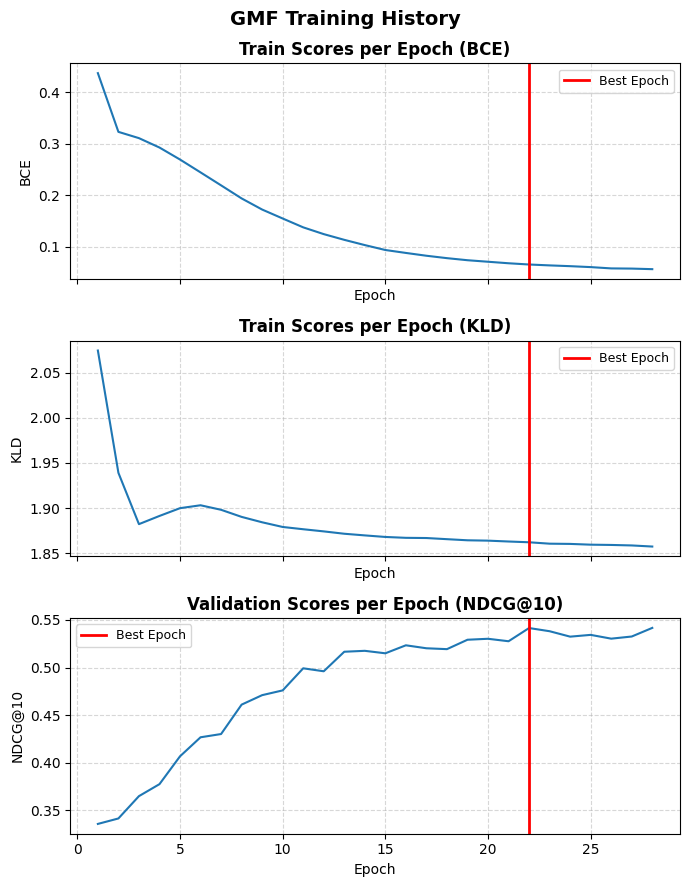

In [16]:
kwargs = dict(
    records=records,
    suptitle="GMF Training History",
    trn="BCE",
    val="NDCG@10",
    figsize=(7,3),
)

utils.visualizer.main(**kwargs)

# Test

In [17]:
kwargs = dict(
    model=model,
    cutoff=[5,10,15,20,25,50],
)

msr = evaluator.build(**kwargs)

In [18]:
result, metrics_sheet = msr(dataloaders["tst"])

TST: 100%|██████████| 799/799 [00:03<00:00, 224.42it/s]


In [19]:
metrics_sheet

,k,hit_ratio,precision,recall,map,ndcg
0,5,0.891447,0.415789,0.343608,0.258961,0.509568
1,10,0.957237,0.318750,0.469545,0.310472,0.521483
2,15,0.975329,0.266118,0.545562,0.334644,0.535533
3,20,0.980263,0.229934,0.598000,0.348274,0.546317
4,25,0.985197,0.205592,0.638324,0.358269,0.556237
5,50,0.995066,0.136349,0.743347,0.379733,0.584434


# Save

In [20]:
PATH = f'./checkpoints/{MODEL_CLS}/{COMB}_{POOLING}_{STRATEGY}.pth'

kwargs = dict(
    obj=model,
    path=PATH,
)

utils.checkpointer.save(**kwargs)